**Técnicas de Aprendizaje Automático**

_Máster Universitario en Inteligencia Artificial_

# Laboratorio: Regresión lineal y árboles de decisión para tareas de regresión


## Objetivos

Mediante esta actividad se pretende que el alumno ponga en práctica los pasos para la resolución de un problema de machine learning, el tratamiento de datos y la creación de modelos basados en regresión lineal y árboles de decisión. El objetivo es comprender de forma práctica con un problema determinado las diferencias que existen a la hora de entrenar los diferentes modelos.

- Iniciarse en el Análisis Exploratorio de Datos (EDA) para los problemas de Machine Learning.
- Entender y aplicar los conceptos de la Regresión Lineal Múltiple a un problema de **regresión**.
- Entender y aplicar los conceptos de Árboles de Decisión a un problema de **regresión**.
- Evaluar y analizar los resultados de los clasificadores.
- Investigar la aplicación de los modelos de **regresión** a problemas reales.


## Descripción de la actividad

Debes completar los espacios indicados en el notebook con el código solicitado y la respuesta en texto, en función de lo que se solicite. Ten en cuenta que las celdas vacías indican cuántas líneas debe ocupar dicha respuesta, por lo general no más de una línea.

El conjunto de datos con el que vamos a trabajar se encuentra en el siguiente enlace: https://archive.ics.uci.edu/dataset/360/air+quality

Se trata de un conjunto de datos (dataset) sobre calidad del aire. En total cuenta con 9358 instancias de respuestas promediadas por hora de una matriz de 5 sensores químicos de óxido de metal integrados en un dispositivo multisensor químico de calidad del aire. El dispositivo estaba ubicado en un área significativamente contaminada, al nivel de la carretera, dentro de una ciudad italiana. Los datos se registraron desde marzo de 2004 hasta febrero de 2005 (un año).

El objetivo de la regresión será predecir la calidad del aire para un determinado día.

### Tareas que se deben realizar

- Análisis descriptivo de los datos:
   - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Regresión:
  - Debe completarse el código solicitado y responder a las preguntas. Todo ello en el notebook dado como base.
- Investigación:
  - Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.
  - Para el artículo indicar:
    - Objetivo: cuál es el objetivo de la investigación, es decir a qué problema real está aplicando la regresión.
    - Cómo utilizan las técnicas de regresión, si realizan alguna adaptación de los algoritmos indicarse.
    - Principales resultados de la aplicación y de la investigación.


### Análisis descriptivo de los datos
A continuación vas a encontrar una serie de preguntas que tendrás que responder. Para responder tendrás que escribir (y ejecutar) una (o más de una) línea de código, y a continuación indicar la respuesta en la celda indicada.

In [68]:


## cargar el dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler

air_quality_dataset = pd.read_csv("./data/AirQualityUCI.csv", sep=";", decimal=",")
#Limpio un poco el dataset

air_quality_dataset.drop(columns=["Unnamed: 15", "Unnamed: 16"], inplace=True)

air_quality_dataset.dropna(inplace=True, how="all")



In [69]:
## ¿cuántas instancias tiene el dataset?
print(f"El dataset tiene {air_quality_dataset.shape[0]} instancias con {air_quality_dataset.shape[1]} columnas")

El dataset tiene 9357 instancias con 15 columnas


tantas instancias

In [70]:
## ¿cuál es el tipo de datos de cada una de las columnas?
air_quality_dataset.info()


<class 'pandas.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), str(2)
memory usage: 1.1 MB


_indica aquí tu respuesta

| # | Column Name    | Dtype   |
|---|----------------|---------|
| 0 |  Date          | str     |
| 1 |  Time          | str     |
| 2 |  CO(GT)        | float64 |
| 3 |  PT08.S1(CO)   | float64 |
| 4 |  NMHC(GT)      | float64 |
| 5 |  C6H6(GT)      | float64 |
| 6 |  PT08.S2(NMHC) | float64 |
| 7 |  NOx(GT)       | float64 |
| 8 |  PT08.S3(NOx)  | float64 |
| 9 |  NO2(GT)       | float64 |
| 10|  PT08.S4(NO2)  | float64 |
| 11|  PT08.S5(O3)   | float64 |
| 12|  T             | float64 |
| 13|  RH            | float64 |
| 14|  AH            | float64 |

In [71]:
## ¿cuántas columnas categóricas hay? ¿y cuántas continuas?

_indica aquí tu respuesta_

* Columnas categóricas: 2 (Date, Time)
* Columnas continuas: 14 (CO(GT), PT08.S1(CO), NMHC(GT), C6H6(GT), PT08.S2(NMHC), NOx(GT), PT08.S3(NOx), NO2(GT), PT08.S4(NO2), PT08.S5(O3), T, RH, AH)
* Sin embargo, es importante destacar que las columnas categóricas (Date y Time) podrían ser transformadas en variables numéricas para su uso en modelos de regresión, dependiendo del enfoque que se quiera tomar para el análisis.
* Adicional todas las variables PT08.S2(NMHC), PT08.S3(NOx), PT08.S4(NO2) y PT08.S5(O3) son consideradas categóricas dentro de la documentación del problema.

In [72]:
## ¿existen valores nulos en el dataset?
# Los valores -200 son valores vacíos
air_quality_dataset.replace(-200,np.nan, inplace=True)
air_quality_dataset.isna().sum()

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

_indica aquí tu respuesta_

* Sí, existen valores nulos en el dataset. Recordar que los valores -200 son considerados valores faltantes por la documentación del problema. Por ahora los asigno a nan a reservas de un análisis posterior.

In [73]:
## ¿cuál es la variable respuesta?¿de qué tipo es? (Recuerda justificar por qué la seleccionas)
air_quality_dataset["C6H6(GT)"].info()

<class 'pandas.Series'>
RangeIndex: 9357 entries, 0 to 9356
Series name: C6H6(GT)
Non-Null Count  Dtype  
--------------  -----  
8991 non-null   float64
dtypes: float64(1)
memory usage: 73.2 KB


_indica aquí tu respuesta_
* Dado el paper original la variable de respuesta es el nivel de benzeno. El problema gira alrededor de realizar el calibrado de la naríz electrónica para el calibrado. Esto es comparado con los resultados de un espectrómetro de gasesa para poder determinar si se puede encontrar una manera de definir los niveles de benzeno de manera práctica y sin recurrir a los espectrómetros. Es de tipo continua y está codificada como float64.

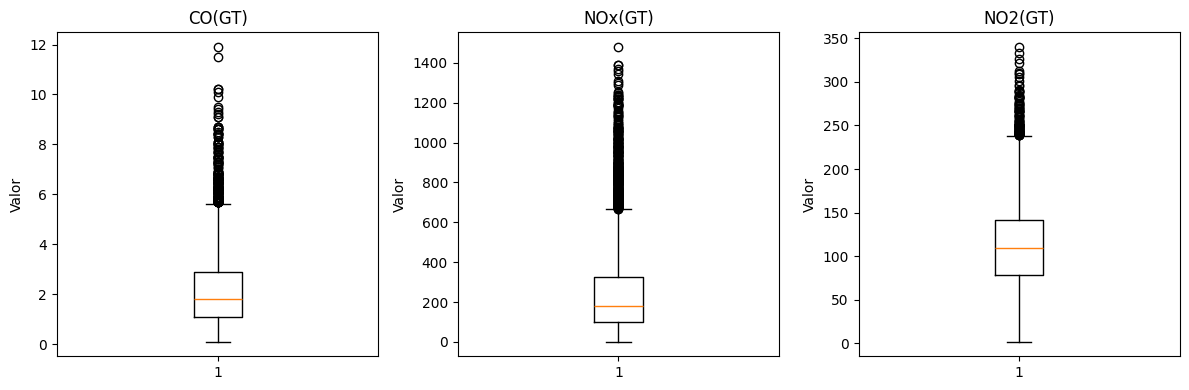

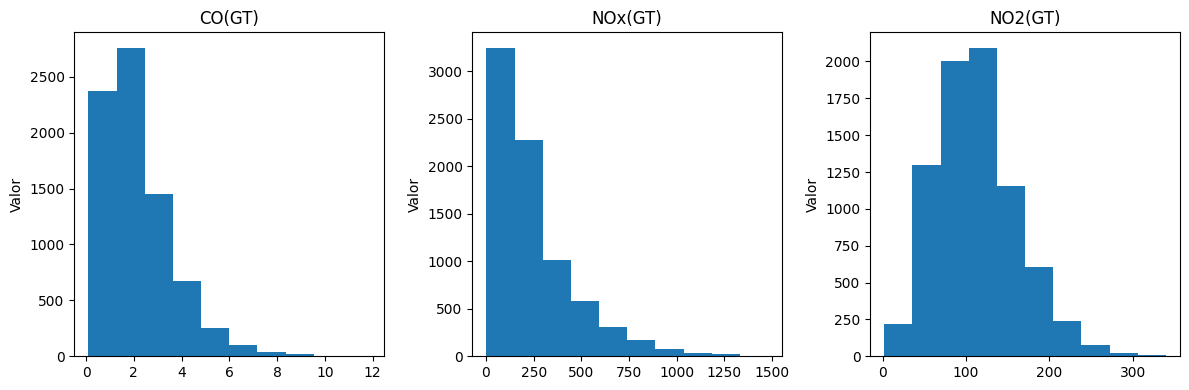

,CO(GT),NOx(GT),NO2(GT)
count,7674.000000,7718.000000,7715.000000
mean,2.152750,246.896735,113.091251
std,1.453252,212.979168,48.370108
min,0.100000,2.000000,2.000000
25%,1.100000,98.000000,78.000000
50%,1.800000,180.000000,109.000000
75%,2.900000,326.000000,142.000000
max,11.900000,1479.000000,340.000000


In [74]:
## Si te fijas en los estadísticos del dataset, ¿cómo es la distribución de las variables, CO, NOx y NO2?
cols=["CO(GT)","NOx(GT)", "NO2(GT)"]
air_quality_dataset[cols].describe(include="all")
columnas = ["CO(GT)", "NOx(GT)", "NO2(GT)"]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, columna in zip(axes, columnas):
    ax.boxplot(air_quality_dataset[columna].dropna())
    ax.set_title(columna)
    ax.set_ylabel("Valor")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, columna in zip(axes, columnas):
    ax.hist(air_quality_dataset[columna].dropna())
    ax.set_title(columna)
    ax.set_ylabel("Valor")

plt.tight_layout()
plt.show()

air_quality_dataset[cols].describe(include="all")


_indica aquí tu respuesta_

Las variables muestran una distribución con skew a la izquierda, una campana parcial asimétrica. Lo que se confirma con una diferencia entre media y mediana prolongada a la derecha.

¿Estas variables muestran alguna distribución especial?¿Tienen datos faltantes?¿y datos anómalos?

_indica aquí tu respuesta_
Existen algunos outliers en las variables mencionadas. Se puede observar en los bigotes una buena cantidad de valores atícos principalmente en la parte superior. De hecho la parte inferior parece estar más concentrada en un rango más estrecho, mientras que la parte superior tiene una mayor dispersión. Esto incinua un skew hacia lña izquierda lo cual es confirmado en los histogramas. Simplemente, para confirmar los estadísticos muestran un maximo muy elevado en comparación con la media y la mediana, lo cual es un indicativo de la presencia de outliers.

<Axes: >

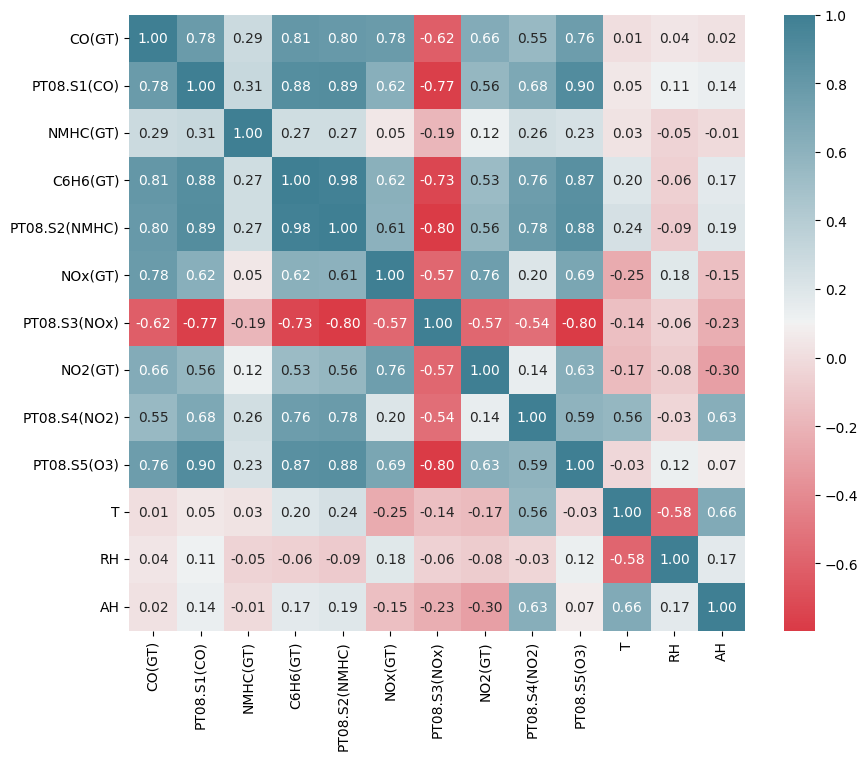

In [75]:
## ¿cómo son las correlaciones entre las variables del dataset?
import seaborn as sns
from  sklearn.impute import SimpleImputer

air_quality_dataset = air_quality_dataset.select_dtypes(include=["number"])

imputer = SimpleImputer(strategy="median")
air_quality_dataset = pd.DataFrame(imputer.fit_transform(air_quality_dataset), columns=air_quality_dataset.columns, index=air_quality_dataset.index)

correlation_matrix = air_quality_dataset.corr(method="pearson")

f, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap=sns.diverging_palette(10, 220, as_cmap=True),
    square=True,
    ax=ax)


_indica aquí tu respuesta_
Hay una fuerte correlación positiva entre el monóxido de carbono y prácticamente todas las variables químicas, la temperatura y la humedad parecen tener las relaciones más débiles. En general las variables químicas parecen ser buenos predictores de la variable objetivo y entre ellas.

<Axes: >

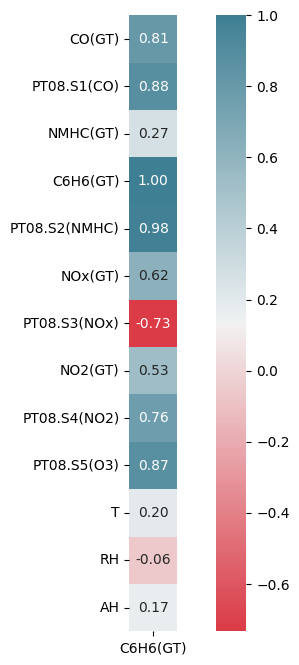

In [76]:
## ¿qué tres variables son las más correlacionadas con la variable objetivo?
f, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(pd.DataFrame(correlation_matrix["C6H6(GT)"]),
    annot=True,
    fmt=".2f",
    cmap=sns.diverging_palette(10, 220, as_cmap=True),
    square=True,
    ax=ax)

_indica aquí tu respuesta_

El monóxido de carbono, PT08.S2(NMHC) y el PT08.S4(NO2) son las variables más correlacionadas con el benzeno.

In [77]:
## ¿existe alguna variable que no tenga correlación?

_indica aquí tu respuesta_

No hay una que tenga una correlación 0, pero la humedad relativa parece ser la que tiene la relación más débil con el benzeno. En general la humedad relativa es la que tiene la relación más débil con el resto de variables.

En base al EDA realizado, ¿qué suposiciones se pueden hacer sobre los datos?¿qué conclusiones extraes para implementar el modelo predictivo?

_indica aquí tu respuesta_

Considerando el EDA podemos decir que:

* La temperatura, humedad relativa y humedad absoluta son los peores predictores para el benzeno, y pueden ser candidatos a ser descartados dentro del modelo.
* El resto de las variables parecen ser buenos predictores aunque me inclino por el monóxido de carbono, el PT08.S2(NMHC) y el PT08.S4(NO2) como los mejores predictores.
* Existen outliers y una discordancia en magnitud dentro de las variables por lo que una normalización es necesaria.
* Las variables no parecen ser lineales por lo que la regresión lineal simple no parece ser la mejor opción, aunque se puede usar como baseline.

### Regresión

Para llevar a cabo la tarea de regresión deseada se pretender hacer una comparativa de varios modelos. Unos usarán el algoritmo de regresión lineal, y otros realizarán la predicción haciendo uso de árboles de decisión.

Para los primeros modelos hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

El algoritmo de Regresión Lineal, necesita saber cuáles son las variables que va a tener en cuenta para realizar la estimación.

El primer modelo que se debe construir, usará una regresión lineal simple. Para ello sigue los siguientes pasos.

Antes de empezar con la implementación de los modelos hace falta realizar una transformación de datos, escalarlos.

In [78]:
standar_scaler = MinMaxScaler()
air_quality_dataset_normalized = pd.DataFrame(standar_scaler.fit_transform(air_quality_dataset), columns = air_quality_dataset.columns, index=air_quality_dataset.index)
air_quality_dataset_normalized.describe()


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,0.168585,0.324043,0.126668,0.155809,0.303099,0.157873,0.217001,0.326548,0.407162,0.347334,0.434356,0.503755,0.410327
std,0.112121,0.152844,0.056733,0.114965,0.142887,0.132086,0.106653,0.130025,0.152594,0.169759,0.186198,0.213521,0.193461
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.093220,0.211055,0.120981,0.070755,0.196614,0.074475,0.145701,0.248521,0.310701,0.226325,0.298925,0.344654,0.274349
50%,0.144068,0.298636,0.120981,0.127358,0.287275,0.120515,0.204998,0.316568,0.410072,0.322328,0.423656,0.508176,0.396178
75%,0.211864,0.412060,0.120981,0.212264,0.394320,0.190928,0.270224,0.387574,0.499550,0.449175,0.559140,0.662893,0.543175
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [79]:
# separar datos de entrenamiento y test
from sklearn.model_selection import train_test_split

X = air_quality_dataset_normalized.drop(columns = ['C6H6(GT)']).copy()
y = air_quality_dataset_normalized['C6H6(GT)']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)



In [80]:
# escoger la variable que a partir del EDA realizado, consideres que mejor va a realizar la predicción
X_train_one_variable = X_train[["PT08.S2(NMHC)"]]
X_test_one_variable = X_test[["PT08.S2(NMHC)"]]

In [81]:
# entrena el modelo con los datos de entrenamiento
from sklearn import linear_model

linear_regression_one_variable = linear_model.LinearRegression()
linear_regression_one_variable.fit(X_train_one_variable, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [82]:
# ¿cuáles son los valores aprendidos por el modelo para los parámetros?
print(f"El valor aprendido para el coeficiente es {linear_regression_one_variable.coef_[0]} y el valor aprendido para la constante es {linear_regression_one_variable.intercept_}")


El valor aprendido para el coeficiente es 0.790707696073986 y el valor aprendido para la constante es -0.08373901120153937


Explica qué indican estos parámetros

_indica aquí tu respuesta_

Los parámetros indican que hay una relación fuerte entre el PT08.S2(NMHC) y el benzeno. Esto es, cuando el PT08.S2(NMHC) aumenta el benzeno aumenta en una proporción similar. El coeficiente indica que para un PT08.S2(NMHC) de 0 el benzeno será 0.00099 aproximadamente lo que manifiesta una recta que cruza casi por el centro de la intersexión de los ejes.

In [83]:
# realiza las predicciones para el conjunto de datos de test
y_predicted = linear_regression_one_variable.predict(X_test_one_variable)

In [84]:
# Ahora es necesario evaluar el modelo. ¿Qué métrica es mejor utilizar en este caso? Justifica tu respuesta.
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

# Calcular métricas
mae = mean_absolute_error(y_test, y_predicted)
mse = mean_squared_error(y_test, y_predicted)
rmse = root_mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)
mape = mean_absolute_percentage_error(y_test, y_predicted)


# Mostrar resultados
print("Evaluación del modelo:")
print(f"MAE  (Mean Absolute Error): {mae:.3f}")
print(f"MSE  (Mean Squared Error): {mse:.3f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.3f}")
print(f"R^2  (Coeficiente de Determinación): {r2:.3f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.3f}%")

Evaluación del modelo:
MAE  (Mean Absolute Error): 0.016
MSE  (Mean Squared Error): 0.000
RMSE (Root Mean Squared Error): 0.021
R^2  (Coeficiente de Determinación): 0.965
MAPE (Mean Absolute Percentage Error): 0.366%


_indica aquí tu respuesta_

In [85]:
# ¿Qué error tiene el modelo? Explícalo.

_indica aquí tu respuesta_

Ahora debes entrenar un segundo modelo que haga uso de una regresión lineal múltiple con **todas las variables** del dataset. Después de entrenar, realiza las predicciones para este segundo modelo.

In [86]:
linear_regression = linear_model.LinearRegression()
linear_regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [87]:
# Coeficientes:
for col, coef in zip(X_train.columns, linear_regression.coef_):
    print(f"El valor aprendido para el coeficiente de {col} es {coef}")
print(f"El valor aprendido para la constante es {linear_regression.intercept_}")

El valor aprendido para el coeficiente de CO(GT) es 0.038830943111170795
El valor aprendido para el coeficiente de PT08.S1(CO) es 0.028908585818969712
El valor aprendido para el coeficiente de NMHC(GT) es 0.003775024520599383
El valor aprendido para el coeficiente de PT08.S2(NMHC) es 0.8585012940133704
El valor aprendido para el coeficiente de NOx(GT) es 0.037782481003020764
El valor aprendido para el coeficiente de PT08.S3(NOx) es 0.15940446004712924
El valor aprendido para el coeficiente de NO2(GT) es -0.047420659741525706
El valor aprendido para el coeficiente de PT08.S4(NO2) es -0.01587330542497503
El valor aprendido para el coeficiente de PT08.S5(O3) es -0.003997367530080481
El valor aprendido para el coeficiente de T es -0.06990318852471539
El valor aprendido para el coeficiente de RH es -0.029100392515645977
El valor aprendido para el coeficiente de AH es 0.050526628687343346
El valor aprendido para la constante es -0.11361475924894965


In [88]:
y_predicted = linear_regression.predict(X_test)
# Calcular métricas
mae = mean_absolute_error(y_test, y_predicted)
mse = mean_squared_error(y_test, y_predicted)
rmse = root_mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)
mape = mean_absolute_percentage_error(y_test, y_predicted)


# Mostrar resultados
print("Evaluación del modelo:")
print(f"MAE  (Mean Absolute Error): {mae:.3f}")
print(f"MSE  (Mean Squared Error): {mse:.3f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.3f}")
print(f"R^2  (Coeficiente de Determinación): {r2:.3f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.3f}%")

Evaluación del modelo:
MAE  (Mean Absolute Error): 0.013
MSE  (Mean Squared Error): 0.000
RMSE (Root Mean Squared Error): 0.017
R^2  (Coeficiente de Determinación): 0.976
MAPE (Mean Absolute Percentage Error): 0.231%


¿Qué error tiene este modelo?¿Es mejor o peor que el anterior?

_indica aquí tu respuesta_

#### Regresión con árboles de decisión

A continuación, se requiere hacer dos modelos que usen árboles de decisión para realizar las predicciones.

Para los árboles de decisión, al ser una tarea de regresión, hay que usar el módulo https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

El algoritmo **DTRegressor** necesita ajustar una serie de hiperparámetros para realizar las predicciones. La implementación de sklearn nos da mucha flexibilidad para nuestros modelos. En general, para los problemas más comunes de regresión, nos tenemos que preocupar de los siguientes hiperparámetros:

* criterion
* splitter
* max_depth
* min_samples_split
* min_samples_leaf
* max_features

**Indica qué son cada uno de estos hiperparámetros**

_indica aquí tu respuesta_

Además de los hiperparámetros que acabas de descubrir, la implementación de sklearn tiene el hiperparámetro min_impurity_decrease

¿Qué indica ese parámetro? ¿Para qué puede ser útil?

_indica aquí tu respuesta_

Entrena un modelo de árboles de decisión donde, el criterio para realizar las particiones sea _poisson_, la profundidad máxima de los árboles debe ser 10, el número mínimo de ejemplos para realizar una partición debe ser 10, el número mínimo de ejemplos para considerarlo una hoja debe ser 2, y el número máximo de características deben ser todas.

In [89]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(criterion='poisson', max_depth=10, min_samples_split=10, min_samples_leaf=2,random_state=0, max_features=None)
tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'poisson'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_node

Calcula MAE, R2 y RMSLE

In [92]:
y_predicted = tree.predict(X_test)
# Calcular métricas
mae = mean_absolute_error(y_test, y_predicted)
mse = mean_squared_error(y_test, y_predicted)
rmse = root_mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)
mape = mean_absolute_percentage_error(y_test, y_predicted)


# Mostrar resultados
print("Evaluación del modelo:")
print(f"MAE  (Mean Absolute Error): {mae:.5f}")
print(f"MSE  (Mean Squared Error): {mse:.5f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.5f}")
print(f"R^2  (Coeficiente de Determinación): {r2:.5f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.5f}%")

Evaluación del modelo:
MAE  (Mean Absolute Error): 0.00024
MSE  (Mean Squared Error): 0.00000
RMSE (Root Mean Squared Error): 0.00124
R^2  (Coeficiente de Determinación): 0.99988
MAPE (Mean Absolute Percentage Error): 0.00198%


¿Existe overfitting? Indica qué debes hacer para comprobar si hay overfitting.

¿Este modelo es mejor, peor o igual que los de regresión lineal simple y múltiple? Razona tu respuesta.

_indica aquí tu respuesta_

**Comparativa**

En base al EDA realizado, a las decisiones tomadas sobre los datos e hiperparámetros y a las características computacionales de tu equipo. ¿Qué modelo obtiene mejores resultados de regresión?

## Investigación

Buscar un artículo científico (https://scholar.google.es/) con un caso de uso de **regresión** empleando una de las dos técnicas (o ambas) vistas en la actividad. Los artículos deben estar en revistas científicas, y deben ser posteriores a 2015. No debe utilizar técnicas de Deep Learning.

_introduce aquí la referencia APA del artículo_

título, autores, revista, año de publicación

Deberás detallar cuál es el **objetivo** de la investigación, es decir a qué problema real está aplicando la regresión. **Técnicas de regresión** empleadas y si se realiza alguna adaptación. Principales **resultados** de la aplicación y de la investigación.